Setup

In [ ]:
!pip install kagglehub pandas numpy seaborn matplotlib scikit-learn

In [ ]:
# Imports
import kagglehub
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset
df = kagglehub.load_dataset(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    'mariankaestner/thk-ddm-processed-data',
    'processed_data.csv')
df = df.drop(columns=['Unnamed: 0'])
display(df.info())

/tmp/ipykernel_8929/2593945271.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 3.36M/3.36M [00:00<00:00, 7.07MB/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   21613 non-null  float64
 1   sqft_living             21613 non-null  float64
 2   bedrooms                21613 non-null  float64
 3   bathrooms               21613 non-null  float64
 4   luxury_score            21613 non-null  float64
 5   distance_to_center      21613 non-null  float64
 6   yard_space_approx       21613 non-null  float64
 7   years_since_renovation  21613 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


None

K-Means

In [ ]:
# Import packages and execute clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

features = df.copy()

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(features)

In [ ]:
# Calculate and print the average for each feature per cluster ---
print("=== Feature Averages for Each Cluster ===")
for i in range(n_clusters):
    # Filter the features belonging to the current cluster
    cluster_data = features[labels == i]

    # Calculate the mean for each column (feature)
    cluster_means = cluster_data.mean()

    print(f"\nCluster {i} Feature Averages (Sample Count: {len(cluster_data)}):")
    print(cluster_means)
print("=========================================\n")

=== Feature Averages for Each Cluster ===

Cluster 0 Feature Averages (Sample Count: 7338):
price                    -0.495121
sqft_living              -0.888995
bedrooms                 -0.613254
bathrooms                -0.981998
luxury_score             -0.266752
distance_to_center       -0.503208
yard_space_approx        -0.137399
years_since_renovation    0.878521
dtype: float64

Cluster 1 Feature Averages (Sample Count: 4935):
price                     1.212608
sqft_living               1.141779
bedrooms                  0.833139
bathrooms                 0.985925
luxury_score              0.935725
distance_to_center       -0.204478
yard_space_approx         0.215967
years_since_renovation   -0.213593
dtype: float64

Cluster 2 Feature Averages (Sample Count: 9340):
price                    -0.251715
sqft_living               0.095157
bedrooms                  0.041597
bathrooms                 0.250574
luxury_score             -0.284837
distance_to_center        0.503387
yard_spa

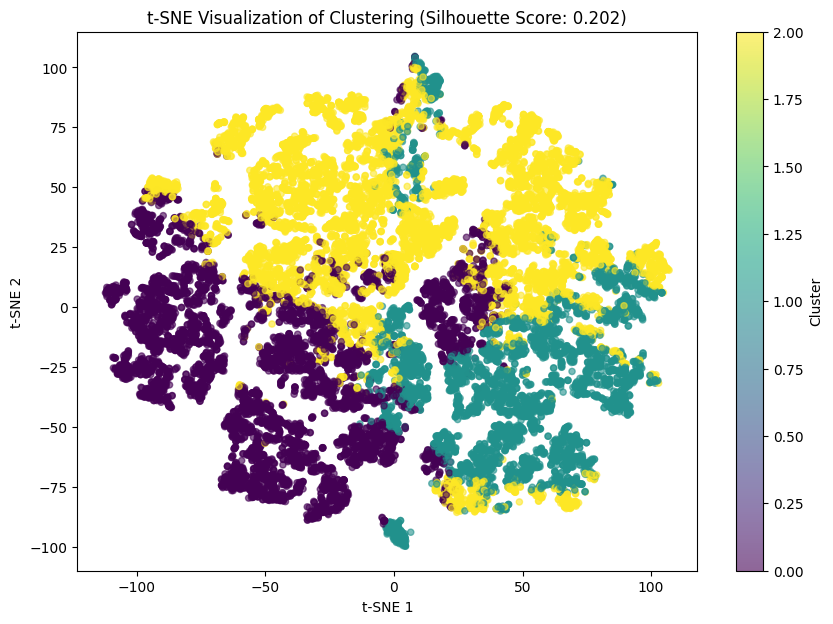

In [ ]:
# Visualize using t-SNE
score = silhouette_score(features, labels)
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 7))
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='viridis', s=20, alpha=0.6)
plt.title(f't-SNE Visualization of Clustering (Silhouette Score: {score:.3f})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.show()

HDBSCAN

In [ ]:
from sklearn.cluster import HDBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Fit HDBSCAN
hdb = HDBSCAN(min_cluster_size=250, max_cluster_size=10000)
hdb_labels = hdb.fit_predict(df)

In [ ]:
# Calculate and print the average for each feature per cluster
# Note: label -1 represents noise in HDBSCAN and is excluded from the cluster loops
unique_labels = [l for l in np.unique(hdb_labels) if l != -1]

print(f"=== HDBSCAN Feature Averages per Cluster (Clusters found: {len(unique_labels)}) ===")

for label in unique_labels:
    # Filter the DataFrame for the current cluster
    cluster_points = df[hdb_labels == label]

    # Calculate the mean for each column (feature)
    cluster_means = cluster_points.mean()

    print(f"\nCluster {label} Feature Averages (Sample Count: {len(cluster_points)}):")
    print(cluster_means)

# Print noise count
noise_count = np.sum(hdb_labels == -1)
print(f"\nNoise points detected: {noise_count}")
print("====================================================\n")

=== HDBSCAN Feature Averages per Cluster (Clusters found: 3) ===

Cluster 0 Feature Averages (Sample Count: 548):
price                    -0.594977
sqft_living              -1.661894
bedrooms                 -1.473959
bathrooms                -1.445686
luxury_score             -0.569189
distance_to_center       -0.838414
yard_space_approx        -0.204456
years_since_renovation    1.109069
dtype: float64

Cluster 1 Feature Averages (Sample Count: 5165):
price                    -0.418765
sqft_living              -0.372618
bedrooms                 -0.398737
bathrooms                -0.208148
luxury_score             -0.350357
distance_to_center        0.069128
yard_space_approx        -0.173644
years_since_renovation   -0.221504
dtype: float64

Cluster 2 Feature Averages (Sample Count: 2837):
price                     0.072758
sqft_living               0.547471
bedrooms                  0.676485
bathrooms                 0.404450
luxury_score             -0.220216
distance_to_center   

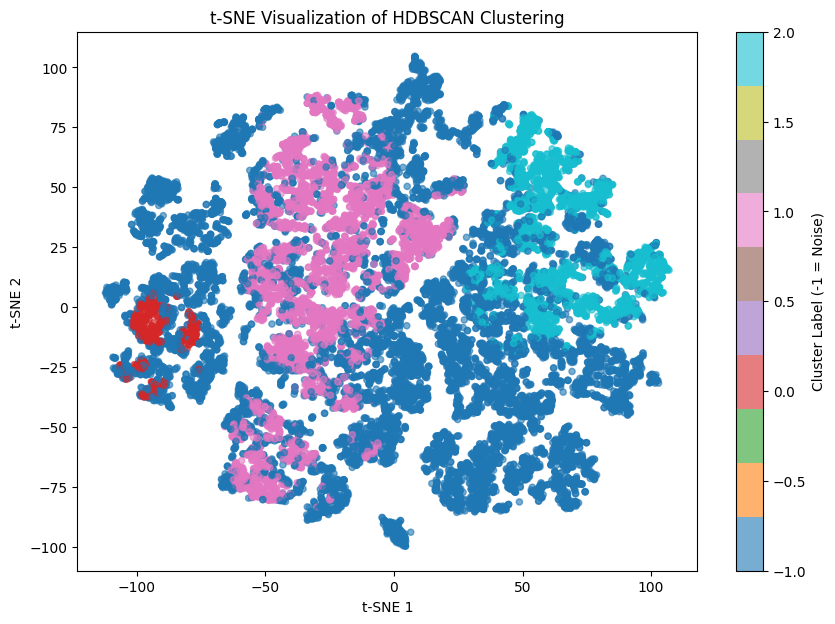

In [ ]:
# Visualize using t-SNE
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(df)

plt.figure(figsize=(10, 7))
# Use a different color map to distinguish from previous steps
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=hdb_labels, cmap='tab10', s=20, alpha=0.6)
plt.title('t-SNE Visualization of HDBSCAN Clustering')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster Label (-1 = Noise)')
plt.show()

Gaussian Mixture Modeling

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Fit Gaussian Mixture Model
n_clusters = 3
gmm = GaussianMixture(n_components=n_clusters, n_init=5, random_state=42)
gmm_labels = gmm.fit_predict(df)

In [ ]:
# Calculate and print the average for each feature per cluster ---
print("=== Feature Averages for Each GMM Cluster ===")
for i in range(n_clusters):
    # Filter the DataFrame for the current cluster based on GMM hard assignments
    cluster_data = df[gmm_labels == i]

    # Calculate the empirical mean for each column (feature)
    cluster_means = cluster_data.mean()

    print(f"\nCluster {i} Feature Averages (Sample Count: {len(cluster_data)}):")
    print(cluster_means)
print("===================================================\n")

=== Feature Averages for Each GMM Cluster ===

Cluster 0 Feature Averages (Sample Count: 11509):
price                    -0.190054
sqft_living              -0.311948
bedrooms                 -0.097443
bathrooms                -0.429790
luxury_score             -0.052405
distance_to_center       -0.343365
yard_space_approx        -0.169545
years_since_renovation    0.611635
dtype: float64

Cluster 1 Feature Averages (Sample Count: 6554):
price                     0.012435
sqft_living               0.191625
bedrooms                  0.037159
bathrooms                 0.505223
luxury_score             -0.391520
distance_to_center        0.241428
yard_space_approx        -0.223848
years_since_renovation   -0.974604
dtype: float64

Cluster 2 Feature Averages (Sample Count: 3550):
price                     0.593191
sqft_living               0.657551
bedrooms                  0.247305
bathrooms                 0.460627
luxury_score              0.892717
distance_to_center        0.667456
yar

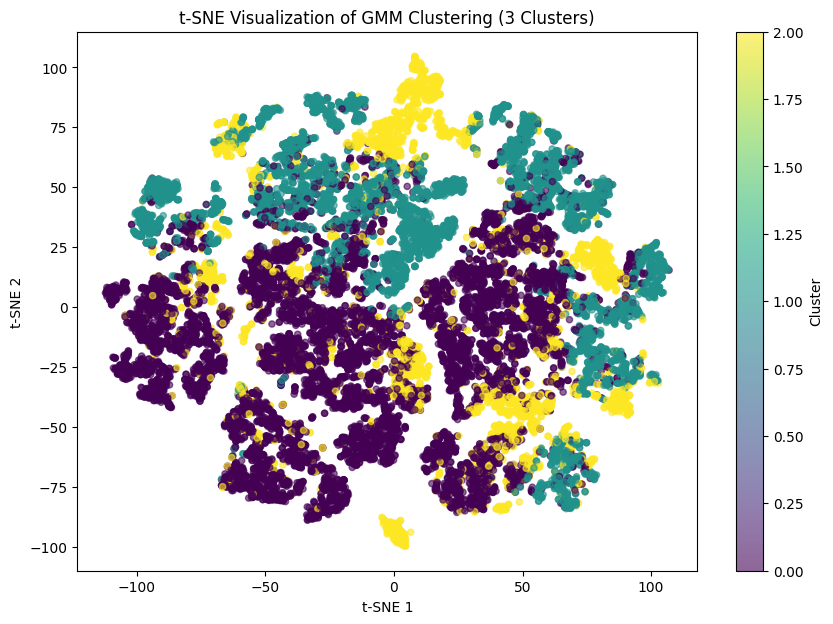

In [ ]:
# Visualize using t-SNE
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(df)

plt.figure(figsize=(10, 7))
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=gmm_labels, cmap='viridis', s=20, alpha=0.6)
plt.title('t-SNE Visualization of GMM Clustering (3 Clusters)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.show()